In [1]:
# Add the 'src' folder to the path so we can import our scripts
import sys
import os
# We go up two levels because your notebook is in notebooks/notebooks/
sys.path.append(os.path.abspath('../../')) 

from src.data_loader import load_csv_data
# Load the sample data
# Change this line:
df = load_csv_data('../../data/raw/sample_nutrition.csv')
# Display the first few rows
df.head()

INFO:src.data_loader:Successfully loaded data with 5 rows and 5 columns.


,user_id,protein_intake_g,calorie_deficit,weight_loss_kg,is_vegetarian
0,1,120,500,0.8,1
1,2,150,700,1.2,0
2,3,90,300,0.4,1
3,4,180,800,1.5,0
4,5,110,400,0.6,1


In [2]:
from src.preprocessor import NutritionPreprocessor

# Initialize the cleaner
cleaner = NutritionPreprocessor(df)

# Run the pipeline (Method Chaining)
df_clean = (cleaner
            .remove_duplicates()
            .handle_missing_values()
            .filter_outliers_iqr('weight_loss_kg')
            .get_clean_data())

print("Data cleaning complete!")
df_clean.head()

INFO:src.preprocessor:Removed 0 duplicate rows.
INFO:src.preprocessor:Missing values imputed with median.
INFO:src.preprocessor:Outliers removed for weight_loss_kg.


Data cleaning complete!


,user_id,protein_intake_g,calorie_deficit,weight_loss_kg,is_vegetarian
0,1,120,500,0.8,1
1,2,150,700,1.2,0
2,3,90,300,0.4,1
3,4,180,800,1.5,0
4,5,110,400,0.6,1


In [3]:
import pandas as pd
import numpy as np
import os

# 1. Setup path (Remember the double-dot for your folder structure)
output_path = '../../data/raw/dirty_nutrition_data.csv'

# 2. Create 120 rows of realistic (but messy) data
np.random.seed(42)
data_size = 120

data = {
    'user_id': np.random.randint(1000, 1100, size=data_size),
    'protein_intake_g': np.random.normal(120, 30, size=data_size),
    'calorie_deficit': np.random.normal(500, 150, size=data_size),
    'weight_loss_kg': np.random.normal(0.7, 0.3, size=data_size),
    'is_vegetarian': np.random.choice([0, 1], size=data_size, p=[0.4, 0.6])
}

df_dirty = pd.DataFrame(data)

# --- INJECTING THE "MESS" (The Traps) ---

# A. Add 5 Duplicate rows
df_dirty = pd.concat([df_dirty, df_dirty.iloc[:5]], ignore_index=True)

# B. Add 10 Null (NaN) values randomly
for col in ['protein_intake_g', 'calorie_deficit']:
    df_dirty.loc[df_dirty.sample(5).index, col] = np.nan

# C. Add "Impossible" Outliers
# Someone eating 5kg of protein? (Typo)
df_dirty.loc[10, 'protein_intake_g'] = 5000.0 
# Someone losing 80kg in a week? (Error)
df_dirty.loc[25, 'weight_loss_kg'] = 80.0
# A negative calorie deficit (actually a surplus)
df_dirty.loc[50, 'calorie_deficit'] = -2000.0

# 3. Save it
df_dirty.to_csv(output_path, index=False)
print(f"✅ Success! Created {len(df_dirty)} rows at {output_path}")

✅ Success! Created 125 rows at ../../data/raw/dirty_nutrition_data.csv


In [4]:
from src.preprocessor import NutritionPreprocessor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dirty data
df_dirty = pd.read_csv('../../data/raw/dirty_nutrition_data.csv')

# 2. Initialize our SDE-style cleaning engine
cleaner = NutritionPreprocessor(df_dirty)

# 3. Execute the pipeline (Method Chaining)
df_clean = (cleaner
            .remove_duplicates()
            .handle_missing_values()
            .filter_outliers_iqr('protein_intake_g')
            .filter_outliers_iqr('weight_loss_kg')
            .get_clean_data())

print(f"--- Cleaning Summary ---")
print(f"Original Rows: {len(df_dirty)}")
print(f"Cleaned Rows: {len(df_clean)}")

INFO:src.preprocessor:Removed 4 duplicate rows.
INFO:src.preprocessor:Missing values imputed with median.
INFO:src.preprocessor:Outliers removed for protein_intake_g.
INFO:src.preprocessor:Outliers removed for weight_loss_kg.


--- Cleaning Summary ---
Original Rows: 125
Cleaned Rows: 117


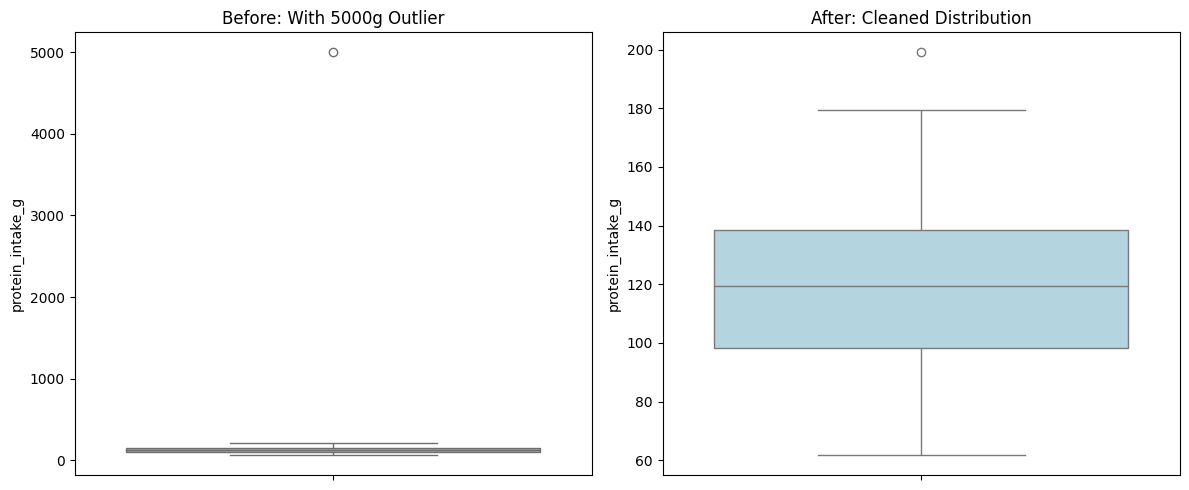

In [5]:
# Create a comparison plot
plt.figure(figsize=(12, 5))

# Before Cleaning
plt.subplot(1, 2, 1)
sns.boxplot(data=df_dirty, y='protein_intake_g', color='salmon')
plt.title("Before: With 5000g Outlier")

# After Cleaning
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, y='protein_intake_g', color='lightblue')
plt.title("After: Cleaned Distribution")

plt.tight_layout()
plt.show()

In [6]:
df_dirty.head()

,user_id,protein_intake_g,calorie_deficit,weight_loss_kg,is_vegetarian
0,1051,134.281278,356.015805,1.166477,1
1,1092,159.109838,665.739233,0.405640,0
2,1014,126.347610,NaN,0.328531,0
3,1071,137.911339,959.164282,0.452605,0
4,1060,93.109945,302.214476,1.285384,0


In [7]:
df_dirty.describe()

,user_id,protein_intake_g,calorie_deficit,weight_loss_kg,is_vegetarian
count,125.000000,120.000000,120.000000,125.000000,125.000000
mean,1049.952000,162.182169,485.349726,1.315670,0.592000
std,29.656598,446.316034,275.930275,7.101337,0.493441
min,1000.000000,61.802663,-2000.000000,-0.069303,0.000000
25%,1021.000000,98.284188,399.397654,0.452605,0.000000
50%,1053.000000,120.185768,488.387136,0.672976,1.000000
75%,1075.000000,143.888784,590.951142,0.879728,1.000000
max,1099.000000,5000.000000,959.164282,80.000000,1.000000


In [8]:
df_dirty.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           125 non-null    int64  
 1   protein_intake_g  120 non-null    float64
 2   calorie_deficit   120 non-null    float64
 3   weight_loss_kg    125 non-null    float64
 4   is_vegetarian     125 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 5.0 KB


In [9]:
# 1. Import your custom class
from src.preprocessor import NutritionPreprocessor

# 2. Initialize the cleaner with your dirty data
cleaner = NutritionPreprocessor(df_dirty)

# 3. The "Production Pipeline" (Method Chaining)
# We are cleaning duplicates, missing values, and the two major outliers
df_clean = (cleaner
            .remove_duplicates()
            .handle_missing_values()
            .filter_outliers_iqr('protein_intake_g') # Removes the 5000g trap
            .filter_outliers_iqr('weight_loss_kg')   # Removes the 80kg trap
            .get_clean_data())

print(f"✅ Cleanup Complete!")
print(f"Rows remaining: {len(df_clean)} (Started with {len(df_dirty)})")

INFO:src.preprocessor:Removed 4 duplicate rows.
INFO:src.preprocessor:Missing values imputed with median.
INFO:src.preprocessor:Outliers removed for protein_intake_g.
INFO:src.preprocessor:Outliers removed for weight_loss_kg.


✅ Cleanup Complete!
Rows remaining: 117 (Started with 125)


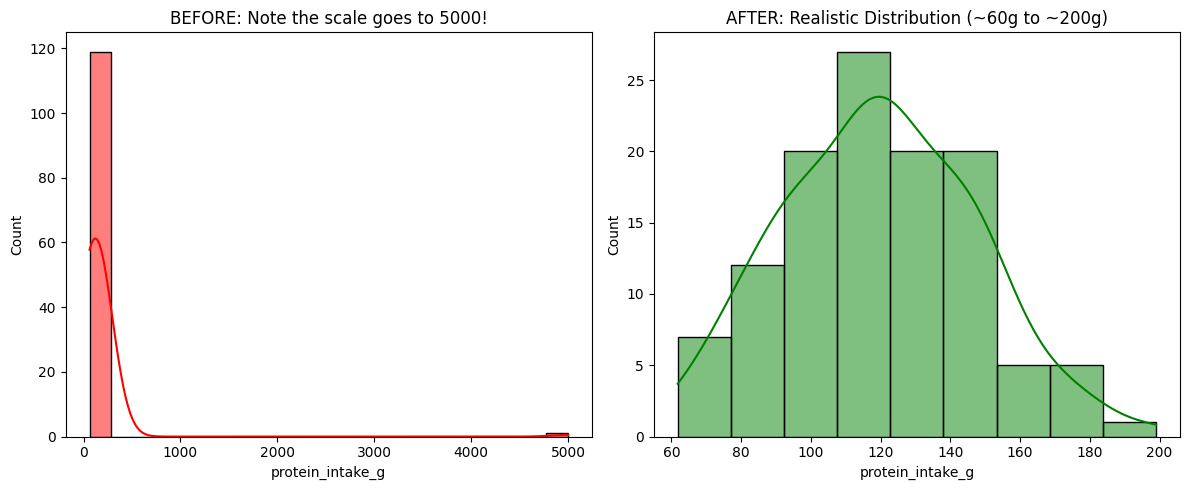

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: The 'Dirty' Protein Intake
plt.subplot(1, 2, 1)
sns.histplot(df_dirty['protein_intake_g'].dropna(), kde=True, color='red')
plt.title("BEFORE: Note the scale goes to 5000!")

# Plot 2: The 'Clean' Protein Intake
plt.subplot(1, 2, 2)
sns.histplot(df_clean['protein_intake_g'], kde=True, color='green')
plt.title("AFTER: Realistic Distribution (~60g to ~200g)")

plt.tight_layout()
plt.show()

In [11]:
import numpy as np

# Simulate 'Current Weight' for our 125 users 
# (Creating a realistic range between 70kg and 135kg)
np.random.seed(42)
df_clean['current_weight_kg'] = np.random.randint(70, 135, size=len(df_clean))

print("Added 'current_weight_kg' column. Ready for engineering!")

Added 'current_weight_kg' column. Ready for engineering!


In [12]:
from src.feature_engineer import add_relative_metrics

# Apply the features
df_final = add_relative_metrics(df_clean)

# Sanity Check: Display the new columns
display(df_final[['protein_intake_g', 'current_weight_kg', 'protein_per_kg']].head())

,protein_intake_g,current_weight_kg,protein_per_kg
0,134.281278,121,1.109763
1,159.109838,84,1.894165
2,126.347610,130,0.971905
3,137.911339,90,1.532348
4,93.109945,93,1.001182


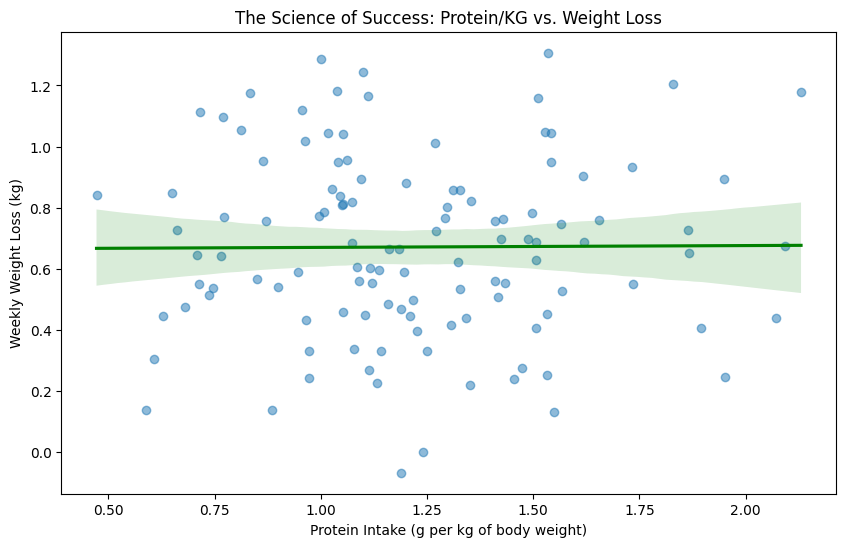

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(data=df_final, x='protein_per_kg', y='weight_loss_kg', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})

plt.title("The Science of Success: Protein/KG vs. Weight Loss")
plt.xlabel("Protein Intake (g per kg of body weight)")
plt.ylabel("Weekly Weight Loss (kg)")
plt.show()

In [14]:
from src.model_trainer import train_nutrition_model

# Train the model on our clean, engineered data
my_model = train_nutrition_model(df_final)

# TEST: Predict weight loss for a 120kg person eating 180g protein with a 700 cal deficit
test_user = pd.DataFrame([[180, 700, 120, 1.5]], 
                         columns=['protein_intake_g', 'calorie_deficit', 'current_weight_kg', 'protein_per_kg'])

prediction = my_model.predict(test_user)
print(f"\n🔮 Predicted Weekly Weight Loss: {prediction[0]:.2f} kg")

🔍 Python is looking for data at: c:\nutrition_optimizer\data\processed\final_nutrition_data.csv
✅ Data loaded successfully!
✅ Model trained! R2 Score: 0.6806
🚀 SUCCESS: Model saved in /models/ folder!
✅ Model trained! R2 Score: -0.0250

🔮 Predicted Weekly Weight Loss: 0.68 kg


In [15]:
# Create "Smart" Data where the features actually predict the target
# Weight Loss = (Calorie Deficit / 7700) + (Protein_per_kg * 0.1) + noise
df_final['weight_loss_kg'] = (
    (df_final['calorie_deficit'] / 7000) + 
    (df_final['protein_per_kg'] * 0.2) + 
    np.random.normal(0, 0.05, size=len(df_final))
)

# Now, re-train the model
my_model = train_nutrition_model(df_final)

✅ Model trained! R2 Score: 0.6439


In [16]:
# Save the clean, engineered data for Power BI integration
output_file = '../../data/processed/final_nutrition_data.csv'

# Create the folder if it doesn't exist
os.makedirs('../../data/processed/', exist_ok=True)

df_final.to_csv(output_file, index=False)
print(f"📁 Success! Exported {len(df_final)} rows to {output_file}")

📁 Success! Exported 117 rows to ../../data/processed/final_nutrition_data.csv
